**Dataset Loading**

The **IMDB Movie Reviews dataset** is used for binary sentiment classification. It contains movie reviews labeled as either **positive** or **negative**.

The dataset is loaded using the Hugging Face `datasets` library. The original dataset provides separate training and test splits, which will be further processed into training, validation, and test sets for the ULMFiT workflow.


In [1]:
from datasets import load_dataset
def load_data():
    dataset = load_dataset("stanfordnlp/imdb")
    return dataset

In [2]:
# Step 1 : Load the dataset
dataset = load_data()
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

**Train–Validation–Test Split**

The original IMDB dataset provides separate **training** and **test** splits.

To create a validation set for model development, **10% of the original training data** is separated as validation data using a fixed random seed of `42`. The original test set is kept completely separate for the final evaluation.

This results in:

* **22,500** training samples
* **2,500** validation samples
* **25,000** test samples


In [3]:
def split_data(dataset):
    train_valid = dataset['train'].train_test_split(test_size=0.1 , seed=42)
    
    train_dataset = train_valid['train']
    valid_dataset = train_valid['test']
    test_dataset  = dataset['test']
    
    return train_dataset, valid_dataset, test_dataset

In [4]:
# Step 2 : Split the dataset into training, validation, and test sets
train_dataset, valid_dataset, test_dataset = split_data(dataset)
print(f"Training samples:   {len(train_dataset):,}")
print(f"Validation samples: {len(valid_dataset):,}")
print(f"Test samples:       {len(test_dataset):,}")

Training samples:   22,500
Validation samples: 2,500
Test samples:       25,000


**Environment Setup and Data Preparation**

The `fastai` library is used to implement the ULMFiT workflow with the AWD-LSTM architecture.

The Hugging Face dataset splits are converted into pandas DataFrames to make them compatible with the `fastai` text APIs. The columns are standardized as `text` and `label`, representing the review text and its binary sentiment label, respectively.


In [5]:
! pip install fastai -q

In [6]:
from fastai.text.all import *
import pandas as pd


In [7]:
train_df = pd.DataFrame(train_dataset)
valid_df = pd.DataFrame(valid_dataset)
test_df  = pd.DataFrame(test_dataset)

train_df.columns = ["text", "label"]
valid_df.columns = ["text", "label"]
test_df.columns  = ["text", "label"]

**Language Model Data Preparation**

For ULMFiT, the language model is trained to predict the next token in a sequence. Since this stage does not require sentiment labels, only the review text is retained.

The training and validation review texts are combined to create the language-model dataset. `fastai` then creates a separate 90/10 training-validation split using a fixed random seed for reproducibility.


In [8]:
lm_texts = pd.concat([train_df["text"], valid_df["text"]]).to_frame()
lm_texts.columns = ["text"]

In [9]:
lm_dataloaders = TextDataLoaders.from_df(
    lm_texts,
    text_col="text",
    is_lm=True,
    valid_pct=0.1,
    seed=42
)

**ULMFiT Language Model Setup**

The **AWD-LSTM** architecture is used as the language model backbone for the ULMFiT approach. The learner is configured with a dropout multiplier of `0.5` to provide regularization during training.

The language model is evaluated using **accuracy** and **perplexity**. Accuracy measures next-token prediction performance, while perplexity evaluates how well the model predicts the sequence of tokens, with lower values indicating better language-model performance.


In [10]:
from fastai.text.all import *

lm_learner = language_model_learner(
    lm_dataloaders,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=[accuracy, Perplexity()]
)

**Learning Rate Finder**

A learning rate range test is performed to identify a suitable learning rate for model training. The resulting plot helps determine a learning rate that provides effective optimization while avoiding unstable or inefficient training.

<div></div>

SuggestedLRs(valley=0.0020892962347716093)

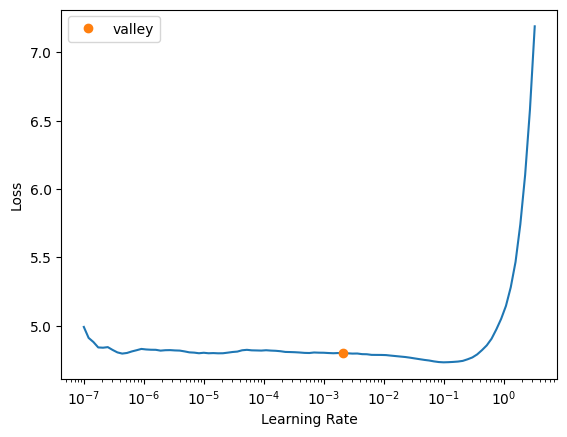

In [11]:
lm_learner.lr_find(show_plot=True)

**Initial Model Training**

The language model is first unfrozen selectively to allow training of the model parameters. The model is then trained using the **One Cycle learning rate policy**, which dynamically adjusts the learning rate throughout training.

A maximum learning rate of `3e-3` is used for **3 training epochs**.

In [12]:
lm_learner.freeze()

lm_learner.fit_one_cycle(3, 3e-3)

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.188378,4.015047,0.290213,55.425877,12:47
1,4.061942,3.940875,0.295919,51.463589,12:41
2,4.008388,3.926380,0.297739,50.723034,12:54


**Save the Pretrained Language Model Encoder**

The trained language model encoder is saved for reuse in the downstream sentiment classification task.

Saving the encoder preserves the learned language representations, allowing them to be transferred to the classifier without retraining the language model from scratch.

In [13]:
lm_learner.save_encoder("pretrained_lm_encoder")

**Prepare the Training and Validation Data**

Separate indicators are assigned to the training and validation datasets to identify which records belong to each split.

The datasets are then combined into a single DataFrame while preserving the split information through the `is_valid` column. This format allows the FastAI data pipeline to recognize the predefined training and validation sets during model training.

In [14]:
train_df["is_valid"] = False
valid_df["is_valid"] = True

classifier_data = pd.concat([train_df, valid_df], ignore_index=True)

In [15]:
print(classifier_data.shape)
print(classifier_data["is_valid"].value_counts())
print(classifier_data["label"].value_counts())

(25000, 3)
is_valid
False    22500
True      2500
Name: count, dtype: int64
label
0    12500
1    12500
Name: count, dtype: int64


**Create the Classification DataLoaders**

A FastAI `TextDataLoaders` object is created from the prepared training and validation data.

The predefined `is_valid` column is used to preserve the training and validation split. The previously learned vocabulary from the language model is also reused so that the classifier uses the same token-to-index mapping as the pretrained language model.

The text and sentiment label columns are specified as `text` and `label`, respectively.

In [16]:
classifier_dataloaders = TextDataLoaders.from_df(
    classifier_data,
    text_col="text",
    label_col="label",
    valid_col="is_valid",
    vocab=lm_dataloaders.vocab   
)

In [17]:
print("LM vocab size:", len(lm_dataloaders.train_ds.vocab))
print("Classifier vocab size:", len(classifier_dataloaders.train_ds.vocab))

LM vocab size: 38392
Classifier vocab size: 2


In [18]:
print(classifier_dataloaders.vocab)

[['xxunk', 'xxpad', 'xxbos', 'xxeos', 'xxfld', 'xxrep', 'xxwrep', 'xxup', 'xxmaj', 'the', '.', ',', 'and', 'a', 'of', 'to', 'is', 'it', 'in', 'i', 'this', 'that', '"', "'s", '-', 'was', '\n\n', 'as', 'for', 'with', 'movie', 'but', 'film', ')', 'on', 'you', "n't", '(', 'not', 'are', 'he', 'his', 'have', 'be', 'one', 'all', 'at', 'they', 'by', 'an', 'who', 'so', 'from', 'like', '!', 'there', 'her', 'or', 'just', 'do', 'about', "'", 'has', 'out', 'if', 'what', 'some', 'good', '?', 'more', 'she', 'when', 'very', 'would', 'up', 'time', 'no', 'even', 'my', 'can', '…', 'which', 'story', 'only', 'really', 'had', 'see', 'their', 'were', 'we', 'me', 'did', 'well', 'does', 'than', 'much', ':', 'could', 'get', 'been', 'people', 'bad', 'will', 'other', 'also', 'into', 'first', 'because', 'great', 'how', 'him', 'most', 'made', 'its', 'then', 'make', 'way', 'them', 'too', 'any', 'movies', 'after', 'think', 'characters', 'character', 'watch', '/', 'two', 'films', 'many', 'seen', 'being', 'life', 'plot

**Build the Sentiment Classification Model**

A text classification learner is created using the prepared classification DataLoaders and the pretrained **AWD-LSTM** architecture.

The model uses a dropout multiplier of `0.5` to help reduce overfitting during classification training. **Accuracy** is used as the evaluation metric to monitor classification performance.

In [19]:
classifier_learner = text_classifier_learner(
    classifier_dataloaders,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy
)

**Transfer the Pretrained Language Model Encoder**

The pretrained language model encoder is loaded into the text classification learner.

This transfers the language representations learned during language model pretraining to the sentiment classification model, providing a pretrained starting point instead of training the classifier from randomly initialized language representations.

In [20]:
classifier_learner.load_encoder("pretrained_lm_encoder")

**Initial Sentiment Classifier Training**

The pretrained encoder is kept frozen during the initial classification training phase. This allows the newly added classification layers to learn the sentiment classification task while preserving the language representations learned during language model pretraining.

The classifier is trained for **2 epochs** using the **One Cycle learning rate policy** with a maximum learning rate of `6.3e-3`.

In [21]:
classifier_learner.freeze()
classifier_learner.fit_one_cycle(2, 6.3e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.398548,0.329755,0.863600,02:34
1,0.360859,0.316259,0.863200,02:33


**Gradual Fine-Tuning of the Sentiment Classifier**

The pretrained classifier is fine-tuned progressively by gradually unfreezing the AWD-LSTM layers.

The model is first trained with the final two layers unfrozen, followed by the final three layers. Finally, the entire model is unfrozen and fine-tuned using discriminative learning rates.

Different learning-rate ranges are used at each stage to carefully adapt the pretrained language representations to the sentiment classification task while minimizing the risk of destroying the previously learned representations.

In [22]:
classifier_learner.freeze_to(-2)
classifier_learner.fit_one_cycle(1, slice(1e-3, 1e-2))

classifier_learner.freeze_to(-3)
classifier_learner.fit_one_cycle(1, slice(1e-4, 1e-3))

classifier_learner.unfreeze()
classifier_learner.fit_one_cycle(2, slice(1e-5, 1e-3))

epoch,train_loss,valid_loss,accuracy,time
0,0.296214,0.249589,0.902000,03:10


epoch,train_loss,valid_loss,accuracy,time
0,0.234366,0.217016,0.915200,05:33


epoch,train_loss,valid_loss,accuracy,time
0,0.215886,0.207968,0.919600,07:22
1,0.186531,0.214849,0.916800,06:52


**Validation Performance**

The fine-tuned sentiment classifier is evaluated on the validation dataset to measure its performance on unseen samples.

Validation loss and validation accuracy are calculated to assess how well the model generalizes beyond the training data.

In [23]:
val_loss, val_acc = classifier_learner.validate()

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Loss: 0.2148
Validation Accuracy: 0.9168


In [24]:
import pandas as pd

test_df = pd.DataFrame(test_dataset)
test_df.columns = ["text", "label"]

**Prepare the Test DataLoader**

A test DataLoader is created from the trained classifier's existing DataLoaders.

The test dataset is processed using the same text preprocessing and vocabulary configuration as the training and validation data. Setting `with_labels=True` includes the ground-truth sentiment labels, allowing the model to be evaluated on the test dataset.

In [25]:
test_dataloader = classifier_learner.dls.test_dl(test_df, with_labels=True)

**Generate Test Set Predictions**

The trained classifier generates predictions for the unseen test dataset using the prepared test DataLoader.

The predicted outputs and corresponding ground-truth labels are stored separately for subsequent evaluation using classification metrics such as accuracy, precision, recall, and F1 score.

In [26]:
raw_predictions, true_labels = classifier_learner.get_preds(dl=test_dataloader)

In [ ]:
predicted_classes = raw_predictions.argmax(dim=1)

true_labels = true_labels.int()   # ensure not None / float issues

**Test Set Evaluation**

The predicted sentiment classes are evaluated against the ground-truth labels from the test dataset.

The following classification metrics are calculated:

- **Accuracy** – proportion of correctly classified reviews.
- **Precision** – proportion of predicted positive reviews that are actually positive.
- **Recall** – proportion of actual positive reviews correctly identified by the model.
- **F1 Score** – harmonic mean of precision and recall.

These metrics provide a comprehensive assessment of the ULMFiT model's performance on unseen test data.

In [28]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

acc = accuracy_score(true_labels, predicted_classes)

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_classes,
    average="binary"
)

print("ULMFiT TEST RESULTS")
print(acc, precision, recall, f1)

ULMFiT TEST RESULTS
0.91836 0.9466985564192364 0.88664 0.9156855455033668


**Export the Trained ULMFiT Model**

The trained ULMFiT sentiment classification model is exported as a `.pkl` file for later reuse.

This preserves the trained model, DataLoaders, vocabulary, and related configuration so the model can be loaded later for inference or deployment without retraining.

In [29]:
classifier_learner.export("ulmfit_model.pkl")

**Prediction with Confidence**

A helper function is defined to generate a sentiment prediction along with its confidence score.

The function:
- Uses the trained FastAI model to predict the sentiment of the input text.
- Extracts the probability associated with the predicted class as the confidence score.
- Converts the numeric class into a human-readable **positive** or **negative** sentiment label.
- Returns both the predicted sentiment and its confidence score.

In [30]:
import torch

def predict_with_confidence(text, learn):
    
    # Get prediction from FastAI
    pred_class, pred_idx, probs = learn.predict(text)
    
    # Extract confidence
    confidence = probs[pred_idx].item()
    
    # Map numeric class to sentiment
    label = "positive" if int(pred_class) == 1 else "negative"
    
    return label, confidence

**Test the ULMFiT Model on a Sample Review**

Samples movie review is passed to the trained ULMFiT sentiment classifier to evaluate its prediction behavior.

The prediction function returns the predicted sentiment together with its confidence score, allowing both the classification result and the model's prediction certainty to be inspected.

In [31]:
text = "An emotionally resonant experience with nuanced performances that stay with you long after the credits roll. The director has crafted a beautiful story that is both intimate and deeply moving. Highly recommended."
result = predict_with_confidence(
    text,
    classifier_learner
)

print(result)

('positive', 1.0)


In [32]:
text = "I grew up...watching and loving [the original]. What they did to this is a disaster...completely ruined the legacy"
result = predict_with_confidence(
    text,
    classifier_learner
)

print(result)

('negative', 0.9975894689559937)
